#*Automação & Visão Computacional*

## Informações

Atualmente, muitas empresas ainda utilizam sistemas legados ou painéis onde as informações
críticas não estão dispostas em formato de texto estruturado, mas representadas visualmente
por meio de cores de status. A proposta do meu projeto é solucionar esse problema de forma
automatizada. Para isso, integrei RPA (Automação Robótica de Processos) para gerar uma
grade de dados, e técnicas de Visão Computacional para realizar a leitura dessas informações
visuais, segmentar as cores correspondentes e auditar os resultados de maneira autônoma.

## RPA

### Configurações

In [1]:
pip install openpyxl Pillow opencv-python-headless xlrd -q

In [2]:
import openpyxl
from openpyxl.styles import PatternFill
import openpyxl.utils
import random
import numpy as np
import cv2
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
import os

print('Bibliotecas importadas.')

Bibliotecas importadas.


In [3]:
matricula_num = 565619

# 1. Configurando a semente aleatória
# Isso garante que a grade gerada será única para a o meu número de matrícula, mas sempre igual ao rodar novamente.
random.seed(matricula_num)

### Inicialização e Definição de cores

In [4]:
# 2. Iniciando o arquivo Excel
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Auditoria Visual"

In [5]:
opcoes_cores = ["FF00FF00", "FFFFFF00", "FFFF0000"]

### Grade 10x10 células

In [6]:
# 3. Gerando a grade de 10x10 células
for linha in range(1, 11):
    # Ajustando a altura da linha para buscar o formato de Quadrado Perfeito
    ws.row_dimensions[linha].height = 40

    for coluna in range(1, 11):
        # O openpyxl precisa da letra da coluna (A, B, C...) para redimensionar a largura
        letra_coluna = openpyxl.utils.get_column_letter(coluna)
        # O Excel usa proporções de medida diferentes para largura e altura.
        # A combinação de largura 8 e altura 40 costuma gerar um visual quadrado na tela.
        ws.column_dimensions[letra_coluna].width = 8

        celula = ws.cell(row=linha, column=coluna)

        # Escolhe uma cor aleatoriamente (que será travada pela seed da matrícula)
        cor_escolhida = random.choice(opcoes_cores)

        # Pinta o fundo da célula com a cor escolhida
        celula.fill = PatternFill(start_color=cor_escolhida, end_color=cor_escolhida, fill_type="solid")

### Salvando o arquivo

In [7]:
nome_arquivo = "tabela_checkpoint.xlsx"
wb.save(nome_arquivo)
print(f"Planilha {nome_arquivo} gerada com sucesso com base na minha matrícula: {matricula_num}")

Planilha tabela_checkpoint.xlsx gerada com sucesso com base na minha matrícula: 565619


### Print Automática

'Print' da planilha capturado e salvo como: matriz_print.png



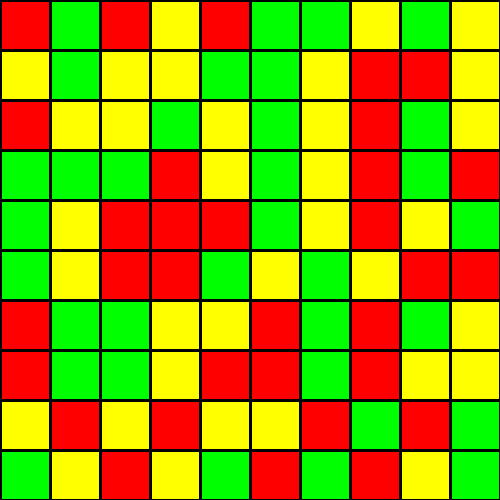

In [8]:
# "Screenshot" da Planilha

# 1. Ajustando as variáveis para o OpenCV rodar
ARQUIVO_IMAGEM = "matriz_print.png"
TAMANHO_CELULA = 50
BORDA = 2
LISTA_CORES = ['Verde', 'Amarelo', 'Vermelho']

CORES = {
    "Verde": {"hex": "FF00FF00", "status": "Sucesso"},
    "Amarelo": {"hex": "FFFFFF00", "status": "Atenção"},
    "Vermelho": {"hex": "FFFF0000", "status": "Crítico"}
}

# 2. Lendo a planilha
wb_leitura = openpyxl.load_workbook("tabela_checkpoint.xlsx")
ws_leitura = wb_leitura.active

# 3. Criando uma "tela" em branco para o print
tamanho_total = TAMANHO_CELULA * 10
imagem_print = Image.new('RGB', (tamanho_total, tamanho_total), color='white')
draw = ImageDraw.Draw(imagem_print)

# 4. Desenhando as células baseadas no Excel
for linha in range(1, 11):
    for coluna in range(1, 11):
        celula = ws_leitura.cell(row=linha, column=coluna)

        cor_hex = "#" + celula.fill.start_color.index[2:]

        x1 = (coluna - 1) * TAMANHO_CELULA
        y1 = (linha - 1) * TAMANHO_CELULA
        x2 = x1 + TAMANHO_CELULA
        y2 = y1 + TAMANHO_CELULA

        draw.rectangle([x1, y1, x2, y2], fill=cor_hex, outline="black", width=BORDA)

imagem_print.save(ARQUIVO_IMAGEM)
print(f"'Print' da planilha capturado e salvo como: {ARQUIVO_IMAGEM}")
print()

display(imagem_print)

## Visão Computacional

In [9]:
#Carregamento e conversão para HSV

img_bgr = cv2.imread(ARQUIVO_IMAGEM)

if img_bgr is None:
    raise FileNotFoundError(f'Imagem não encontrada: {ARQUIVO_IMAGEM}')

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f'Imagem carregada: {ARQUIVO_IMAGEM}')
print(f'\n Dimensões: {img_bgr.shape[1]}x{img_bgr.shape[0]} px (LxA)')
print(f' Canais: {img_bgr.shape[2]} (BGR)')
print(f'\n Espaço HSV:')
print(f'   H (Hue/Matiz): 0-179 no OpenCV')
print(f'   S (Saturation/Saturação): 0-255')
print(f'   V (Value/Brilho): 0-255')

Imagem carregada: matriz_print.png

 Dimensões: 500x500 px (LxA)
 Canais: 3 (BGR)

 Espaço HSV:
   H (Hue/Matiz): 0-179 no OpenCV
   S (Saturation/Saturação): 0-255
   V (Value/Brilho): 0-255


In [10]:
#Definição dos intervalos HSV para cada cor

# Formato: [H_min, S_min, V_min], [H_max, S_max, V_max]
HSV_RANGES = {
    'Verde': {
        'lower': np.array([55,  100, 50]),
        'upper': np.array([85,  255, 255]),
    },
    'Amarelo': {
        'lower': np.array([25,  100, 100]),
        'upper': np.array([35,  255, 255]),
    },
    'Vermelho': {
        'lower1': np.array([0,   120, 70]),
        'upper1': np.array([10,  255, 255]),
        'lower2': np.array([160, 120, 70]),
        'upper2': np.array([179, 255, 255]),
    },
}

print('Intervalos HSV configurados para cada cor:')
for cor, faixas in HSV_RANGES.items():
    if cor == 'Vermelho':
        print(f'   {cor}: [{faixas["lower1"]} - {faixas["upper1"]}] ∪ [{faixas["lower2"]} - {faixas["upper2"]}]')
    else:
        print(f'   {cor}: [{faixas["lower"]} - {faixas["upper"]}]')

Intervalos HSV configurados para cada cor:
   Verde: [[ 55 100  50] - [ 85 255 255]]
   Amarelo: [[ 25 100 100] - [ 35 255 255]]
   Vermelho: [[  0 120  70] - [ 10 255 255]] ∪ [[160 120  70] - [179 255 255]]


In [11]:
#Criação das máscaras e contagem por célula

mascaras = {}
contagem_cv = {}

AREA_CELULA = (TAMANHO_CELULA - BORDA) ** 2
LIMIAR_PIXELS = AREA_CELULA * 0.3

print(f'Área por célula: {AREA_CELULA} px | Limiar de detecção: {LIMIAR_PIXELS:.0f} px')
print()

for cor in LISTA_CORES:
    if cor == 'Vermelho':
        # Vermelho
        mask1 = cv2.inRange(img_hsv, HSV_RANGES[cor]['lower1'], HSV_RANGES[cor]['upper1'])
        mask2 = cv2.inRange(img_hsv, HSV_RANGES[cor]['lower2'], HSV_RANGES[cor]['upper2'])
        mascara = cv2.add(mask1, mask2)  # União das duas máscaras
    else:
        # Verde e Amarelo
        mascara = cv2.inRange(img_hsv, HSV_RANGES[cor]['lower'], HSV_RANGES[cor]['upper'])

    mascaras[cor] = mascara

    # ---- Contagem via análise de contornos ----
    # Aplica morfologia para limpar ruídos da máscara
    kernel = np.ones((3, 3), np.uint8)
    mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

    # Encontra contornos de regiões conectadas
    contornos, _ = cv2.findContours(mascara_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filtra contornos pequenos (ruído) e conta apenas os que têm área suficiente
    celulas_detectadas = sum(1 for c in contornos if cv2.contourArea(c) >= LIMIAR_PIXELS)

    contagem_cv[cor] = celulas_detectadas

    total_pixels = cv2.countNonZero(mascara)
    print(f'   {cor:10s}: {celulas_detectadas:3d} células | {total_pixels:6d} pixels detectados | {len(contornos):3d} contornos')

print(f'\n   Total CV: {sum(contagem_cv.values())} células')

Área por célula: 2304 px | Limiar de detecção: 691 px

   Verde     :  34 células |  75106 pixels detectados |  34 contornos
   Amarelo   :  34 células |  75106 pixels detectados |  34 contornos
   Vermelho  :  32 células |  70688 pixels detectados |  32 contornos

   Total CV: 100 células


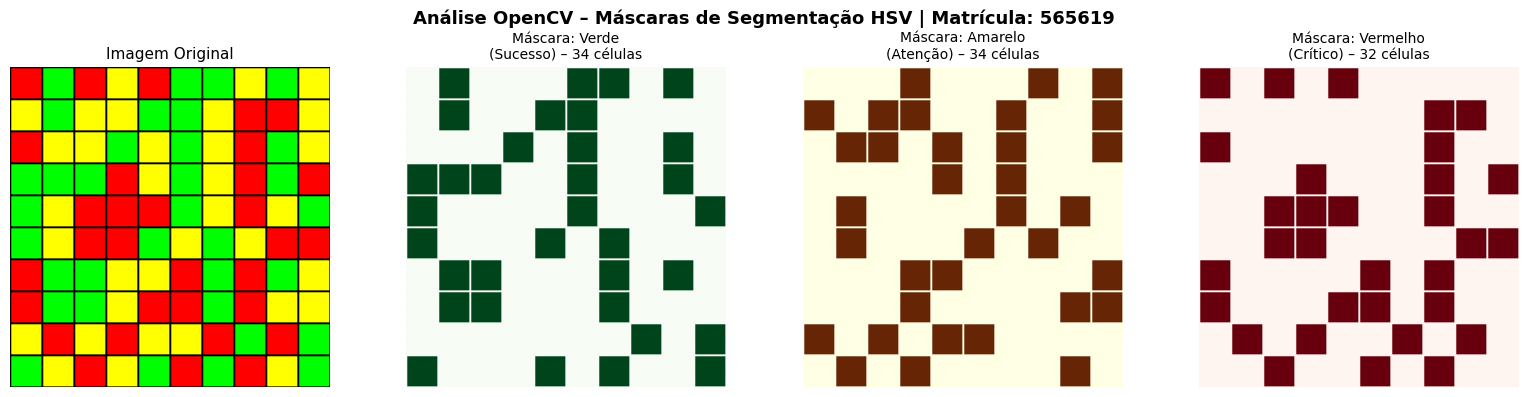


 Máscaras salvas em: mascaras_hsv_565619.png


In [12]:
#Visualização das máscaras geradas

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'Análise OpenCV – Máscaras de Segmentação HSV | Matrícula: {matricula_num}',
             fontsize=13, fontweight='bold')

# Imagem original
axes[0].imshow(img_rgb)
axes[0].set_title('Imagem Original', fontsize=11)
axes[0].axis('off')

# Cores para exibição das máscaras
CMAP_MASCARAS = {
    'Verde':    'Greens',
    'Amarelo':  'YlOrBr',
    'Vermelho': 'Reds',
}

for i, cor in enumerate(LISTA_CORES):
    ax = axes[i + 1]
    ax.imshow(mascaras[cor], cmap=CMAP_MASCARAS[cor])
    ax.set_title(
        f'Máscara: {cor}\n({CORES[cor]["status"]}) – {contagem_cv[cor]} células',
        fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
ARQUIVO_MASCARAS = f'mascaras_hsv_{matricula_num}.png'
plt.savefig(ARQUIVO_MASCARAS, dpi=120, bbox_inches='tight')
plt.show()
print(f'\n Máscaras salvas em: {ARQUIVO_MASCARAS}')

## Relatório de Auditoria

In [13]:
import pandas as pd

contagem_rpa = {"Verde": 0, "Amarelo": 0, "Vermelho": 0}

for linha in range(1, 11):
    for coluna in range(1, 11):
        celula = ws_leitura.cell(row=linha, column=coluna)
        cor_hex = celula.fill.start_color.index

        if cor_hex == "FF00FF00":
            contagem_rpa["Verde"] += 1
        elif cor_hex == "FFFFFF00":
            contagem_rpa["Amarelo"] += 1
        elif cor_hex == "FFFF0000":
            contagem_rpa["Vermelho"] += 1

df_auditoria = pd.DataFrame({
    "Cor / Status": ["Verde (Sucesso)", "Amarelo (Atenção)", "Vermelho (Crítico)"],
    "Gerado (RPA)": [contagem_rpa["Verde"], contagem_rpa["Amarelo"], contagem_rpa["Vermelho"]],
    "Detectado (CV)": [contagem_cv["Verde"], contagem_cv["Amarelo"], contagem_cv["Vermelho"]]
})

df_auditoria["Diferença"] = df_auditoria["Gerado (RPA)"] - df_auditoria["Detectado (CV)"]
df_auditoria["Acurácia (%)"] = (df_auditoria["Detectado (CV)"] / df_auditoria["Gerado (RPA)"]) * 100

display(df_auditoria)

acuracia_total = (df_auditoria["Detectado (CV)"].sum() / df_auditoria["Gerado (RPA)"].sum()) * 100

if acuracia_total == 100.0:
    print("\n Conclusão: A acurácia do pipeline visual foi de 100%. Todas as células geradas foram identificadas corretamente.")
else:
    print(f"\n Conclusão: Houve divergência na detecção. A acurácia total da Visão Computacional foi de {acuracia_total:.2f}%.")

,Cor / Status,Gerado (RPA),Detectado (CV),Diferença,Acurácia (%)
0,Verde (Sucesso),34,34,0,100.0
1,Amarelo (Atenção),34,34,0,100.0
2,Vermelho (Crítico),32,32,0,100.0



 Conclusão: A acurácia do pipeline visual foi de 100%. Todas as células geradas foram identificadas corretamente.
